In [2]:
# =============================================================================
# CodeAlpha Internship — Task 4: Sales Prediction using Python
# Author  :Richard Samuel Yaw Okai
# Dataset : Advertising.csv
# Libraries: Pandas, Scikit-learn, Matplotlib, Seaborn
# =============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [3]:
# ── 1. LOAD DATA ──────────────────────────────────────────────────────────────
df = pd.read_csv("Advertising.csv")

# Drop unnamed index column if present
df.drop(columns=[c for c in df.columns if "Unnamed" in c], inplace=True, errors="ignore")

print("=" * 60)
print("SALES PREDICTION USING PYTHON")
print("=" * 60)
print(f"\nDataset shape : {df.shape}")
print(f"Columns       : {list(df.columns)}")
print(f"\nFirst 5 rows:\n{df.head()}")
print(f"\nMissing values:\n{df.isnull().sum()}")
print(f"\nDescriptive stats:\n{df.describe()}")

SALES PREDICTION USING PYTHON

Dataset shape : (200, 4)
Columns       : ['TV', 'Radio', 'Newspaper', 'Sales']

First 5 rows:
      TV  Radio  Newspaper  Sales
0  230.1   37.8       69.2   22.1
1   44.5   39.3       45.1   10.4
2   17.2   45.9       69.3    9.3
3  151.5   41.3       58.5   18.5
4  180.8   10.8       58.4   12.9

Missing values:
TV           0
Radio        0
Newspaper    0
Sales        0
dtype: int64

Descriptive stats:
               TV       Radio   Newspaper       Sales
count  200.000000  200.000000  200.000000  200.000000
mean   147.042500   23.264000   30.554000   14.022500
std     85.854236   14.846809   21.778621    5.217457
min      0.700000    0.000000    0.300000    1.600000
25%     74.375000    9.975000   12.750000   10.375000
50%    149.750000   22.900000   25.750000   12.900000
75%    218.825000   36.525000   45.100000   17.400000
max    296.400000   49.600000  114.000000   27.000000


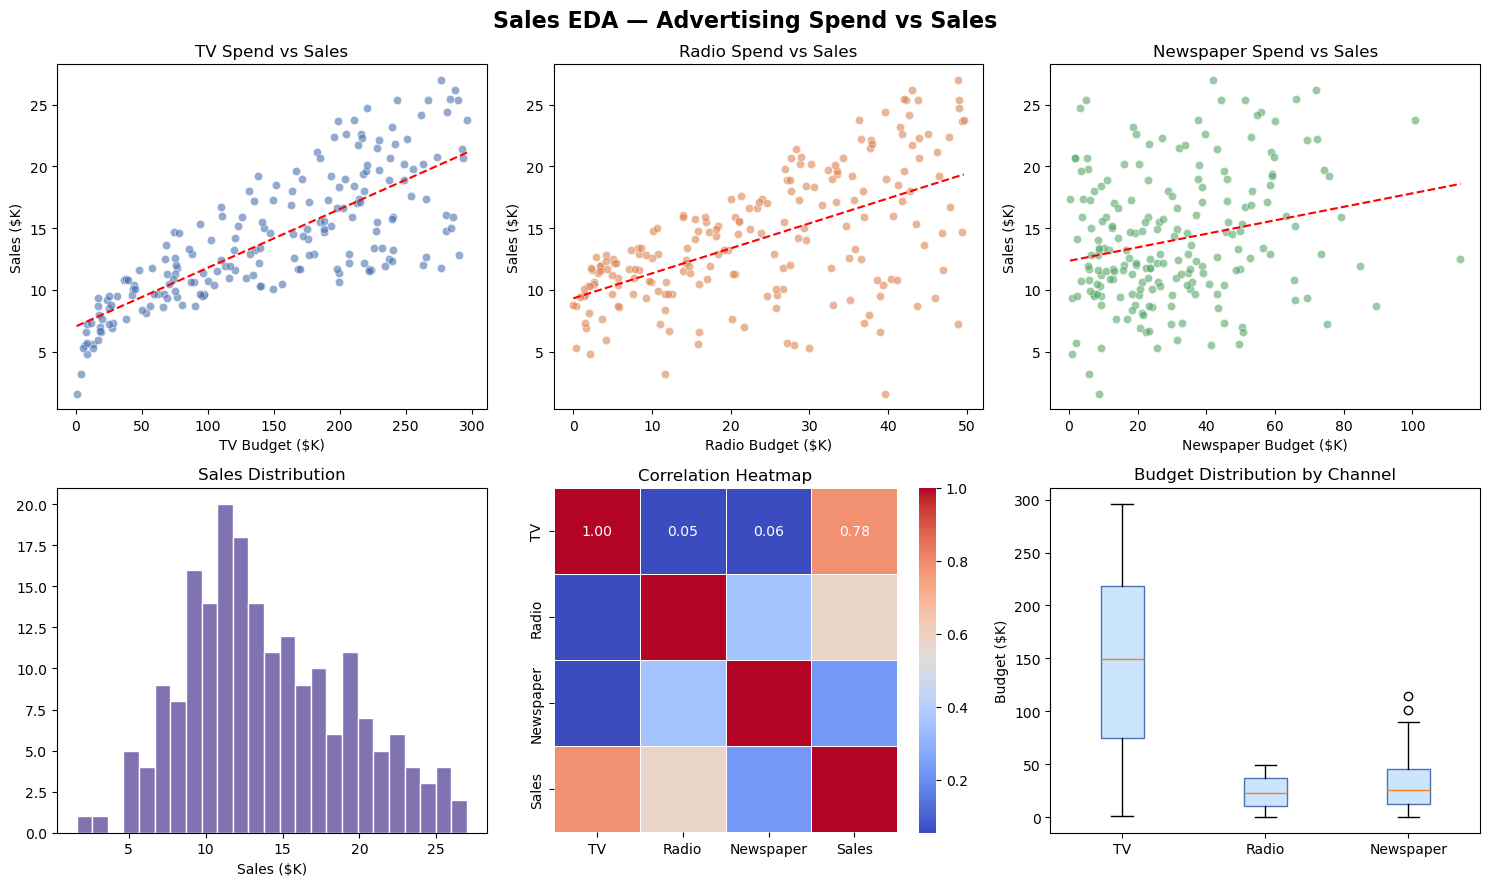


[Saved] sales_eda.png


In [4]:
# ── 2. EDA ────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
fig.suptitle("Sales EDA — Advertising Spend vs Sales", fontsize=16, fontweight="bold")

channels = ["TV", "Radio", "Newspaper"]
colors   = ["#4C72B0", "#DD8452", "#55A868"]

# Scatter plots
for i, (ch, col) in enumerate(zip(channels, colors)):
    axes[0, i].scatter(df[ch], df["Sales"], alpha=0.6, color=col,
                       edgecolors="white", linewidth=0.5)
    # Trend line
    z = np.polyfit(df[ch], df["Sales"], 1)
    p = np.poly1d(z)
    x_sorted = np.sort(df[ch])
    axes[0, i].plot(x_sorted, p(x_sorted), "r--", linewidth=1.5)
    axes[0, i].set_title(f"{ch} Spend vs Sales")
    axes[0, i].set_xlabel(f"{ch} Budget ($K)")
    axes[0, i].set_ylabel("Sales ($K)")

# Distribution of Sales
axes[1, 0].hist(df["Sales"], bins=25, color="#8172B2", edgecolor="white")
axes[1, 0].set_title("Sales Distribution")
axes[1, 0].set_xlabel("Sales ($K)")

# Correlation heatmap
corr = df.corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm",
            ax=axes[1, 1], square=True, linewidths=0.5)
axes[1, 1].set_title("Correlation Heatmap")

# Advertising budget split (boxplot)
df_melt = df[channels].melt(var_name="Channel", value_name="Budget")
axes[1, 2].boxplot(
    [df[ch] for ch in channels],
    labels=channels,
    patch_artist=True,
    boxprops=dict(facecolor="#CCE5FF", color="#4C72B0"),
)
axes[1, 2].set_title("Budget Distribution by Channel")
axes[1, 2].set_ylabel("Budget ($K)")

plt.tight_layout()
plt.savefig("sales_eda.png", dpi=150)
plt.show()
print("\n[Saved] sales_eda.png")


In [5]:
# ── 3. ADVERTISING IMPACT ANALYSIS ───────────────────────────────────────────
print("\n── Correlation with Sales ──")
for ch in channels:
    corr_val = df[ch].corr(df["Sales"])
    print(f"  {ch:12s}: {corr_val:.4f}")


── Correlation with Sales ──
  TV          : 0.7822
  Radio       : 0.5762
  Newspaper   : 0.2283


In [6]:
# ── 4. FEATURE ENGINEERING ────────────────────────────────────────────────────
df["TV_Radio_Interaction"] = df["TV"] * df["Radio"]
df["Total_Budget"]         = df["TV"] + df["Radio"] + df["Newspaper"]
df["TV_Share"]             = df["TV"] / df["Total_Budget"]

features_base     = ["TV", "Radio", "Newspaper"]
features_enhanced = ["TV", "Radio", "Newspaper",
                     "TV_Radio_Interaction", "Total_Budget", "TV_Share"]

X = df[features_enhanced]
y = df["Sales"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"\nTrain size: {X_train.shape[0]} | Test size: {X_test.shape[0]}")



Train size: 160 | Test size: 40


In [7]:
# ── 5. TRAIN MODELS ───────────────────────────────────────────────────────────
models = {
    "Linear Regression"      : LinearRegression(),
    "Ridge Regression"       : Ridge(alpha=1.0),
    "Lasso Regression"       : Lasso(alpha=0.1),
    "Random Forest"          : RandomForestRegressor(n_estimators=100, random_state=42),
    "Gradient Boosting"      : GradientBoostingRegressor(n_estimators=100, random_state=42),
    "Polynomial Regression"  : Pipeline([
        ("poly", PolynomialFeatures(degree=2, include_bias=False)),
        ("lin",  LinearRegression())
    ]),
}

results = {}
print("\n" + "=" * 60)
print("MODEL EVALUATION")
print("=" * 60)

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    mae  = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2   = r2_score(y_test, y_pred)

    results[name] = {"MAE": mae, "RMSE": rmse, "R2": r2, "model": model, "y_pred": y_pred}
    print(f"\n── {name} ──")
    print(f"  MAE  : {mae:.3f}")
    print(f"  RMSE : {rmse:.3f}")
    print(f"  R²   : {r2:.4f}")



MODEL EVALUATION

── Linear Regression ──
  MAE  : 0.355
  RMSE : 0.448
  R²   : 0.9937

── Ridge Regression ──
  MAE  : 0.442
  RMSE : 0.543
  R²   : 0.9907

── Lasso Regression ──
  MAE  : 0.672
  RMSE : 0.899
  R²   : 0.9744

── Random Forest ──
  MAE  : 0.439
  RMSE : 0.551
  R²   : 0.9904

── Gradient Boosting ──
  MAE  : 0.460
  RMSE : 0.597
  R²   : 0.9887

── Polynomial Regression ──
  MAE  : 0.354
  RMSE : 0.468
  R²   : 0.9931


In [8]:
# ── 6. BEST MODEL ─────────────────────────────────────────────────────────────
best_name = max(results, key=lambda k: results[k]["R2"])
best      = results[best_name]
print("\n" + "=" * 60)
print(f"Best Model : {best_name}")
print(f"  R²   : {best['R2']:.4f}")
print(f"  MAE  : {best['MAE']:.3f}")
print(f"  RMSE : {best['RMSE']:.3f}")
print("=" * 60)



Best Model : Linear Regression
  R²   : 0.9937
  MAE  : 0.355
  RMSE : 0.448


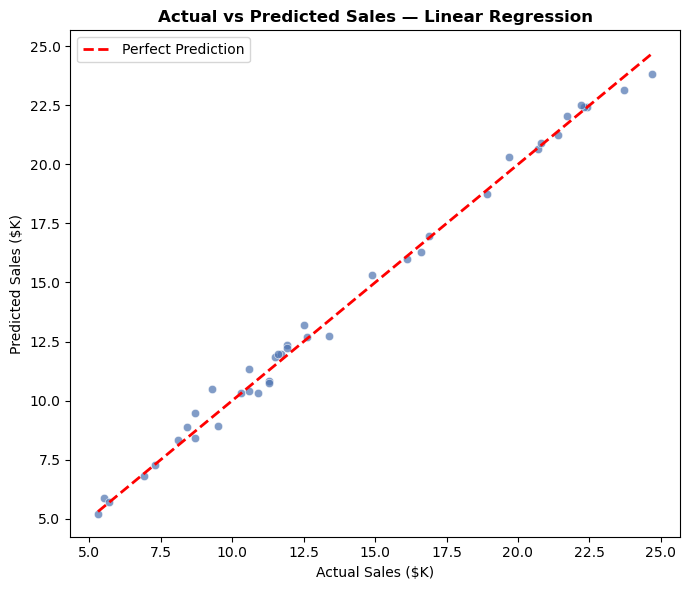

[Saved] sales_actual_vs_predicted.png


In [9]:
# ── 7. ACTUAL vs PREDICTED ────────────────────────────────────────────────────
plt.figure(figsize=(7, 6))
plt.scatter(y_test, best["y_pred"], alpha=0.7, color="#4C72B0",
            edgecolors="white", linewidth=0.5)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()], "r--", linewidth=2, label="Perfect Prediction")
plt.title(f"Actual vs Predicted Sales — {best_name}", fontweight="bold")
plt.xlabel("Actual Sales ($K)")
plt.ylabel("Predicted Sales ($K)")
plt.legend()
plt.tight_layout()
plt.savefig("sales_actual_vs_predicted.png", dpi=150)
plt.show()
print("[Saved] sales_actual_vs_predicted.png")

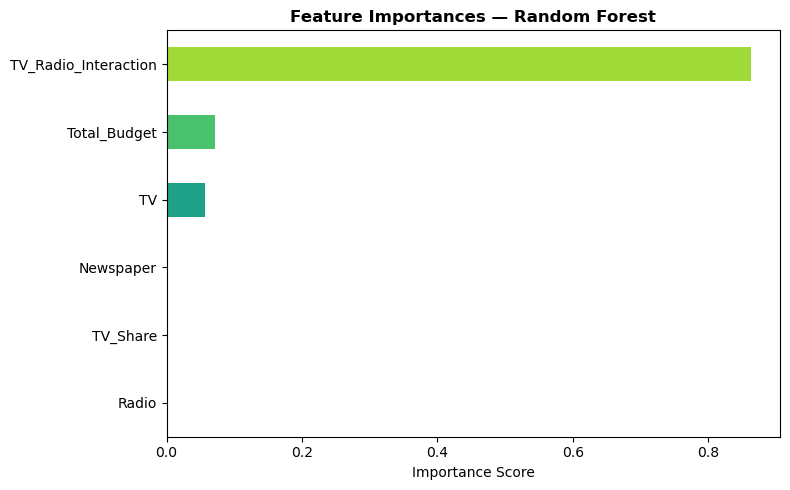

[Saved] sales_feature_importance.png


In [10]:
# ── 8. FEATURE IMPORTANCE (Random Forest) ─────────────────────────────────────
rf = results["Random Forest"]["model"]
importance = pd.Series(rf.feature_importances_, index=features_enhanced).sort_values()

plt.figure(figsize=(8, 5))
importance.plot(kind="barh", color=sns.color_palette("viridis", len(importance)))
plt.title("Feature Importances — Random Forest", fontweight="bold")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.savefig("sales_feature_importance.png", dpi=150)
plt.show()
print("[Saved] sales_feature_importance.png")

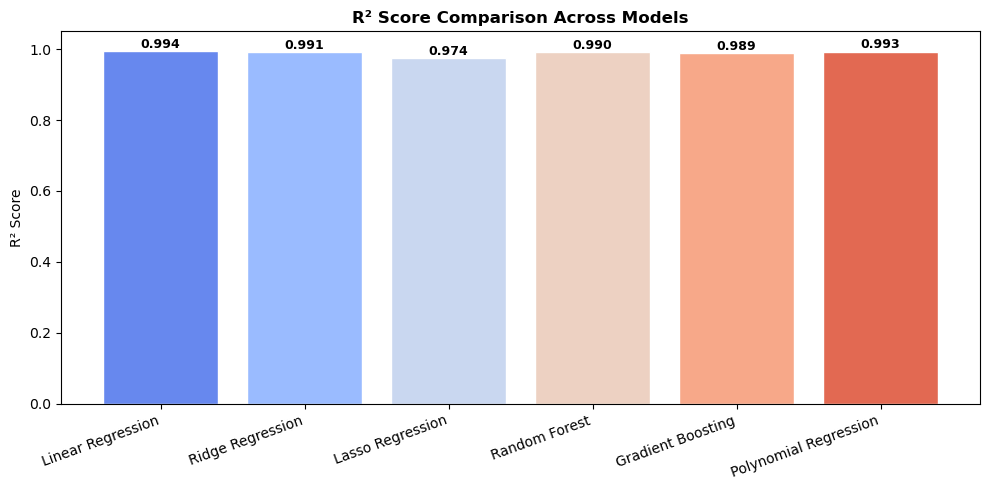

[Saved] sales_model_r2_comparison.png


In [11]:
# ── 9. MODEL R² COMPARISON ────────────────────────────────────────────────────
r2_scores = {k: v["R2"] for k, v in results.items()}
plt.figure(figsize=(10, 5))
bars = plt.bar(r2_scores.keys(), r2_scores.values(),
               color=sns.color_palette("coolwarm", len(r2_scores)), edgecolor="white")
plt.ylabel("R² Score")
plt.title("R² Score Comparison Across Models", fontweight="bold")
plt.xticks(rotation=20, ha="right")
plt.ylim(0, 1.05)
for bar, val in zip(bars, r2_scores.values()):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
             f"{val:.3f}", ha="center", fontsize=9, fontweight="bold")
plt.tight_layout()
plt.savefig("sales_model_r2_comparison.png", dpi=150)
plt.show()
print("[Saved] sales_model_r2_comparison.png")


In [12]:
# ── 11. SAMPLE PREDICTION ─────────────────────────────────────────────────────
sample = pd.DataFrame([{
    "TV"                  : 150.0,
    "Radio"               : 30.0,
    "Newspaper"           : 20.0,
    "TV_Radio_Interaction": 150.0 * 30.0,
    "Total_Budget"        : 200.0,
    "TV_Share"            : 150.0 / 200.0,
}])
pred_sales = best["model"].predict(sample)[0]
print(f"\nSample Prediction (TV=$150K, Radio=$30K, Newspaper=$20K)")
print(f"  → Predicted Sales: ${pred_sales:.2f}K")
print("\nTask 4 Complete!")


Sample Prediction (TV=$150K, Radio=$30K, Newspaper=$20K)
  → Predicted Sales: $15.90K

Task 4 Complete!
